In [1]:
pip install numpy pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df= pd.DataFrame({
    'study_hours':[1,2,3,4,5,6,7,8,9,10],
    'marks':[10,20,30,40,50,60,70,80,90,100]
})
df.head()

,study_hours,marks
0,1,10
1,2,20
2,3,30
3,4,40
4,5,50


In [9]:
X=df[['study_hours']]
y=df['marks']

X_train,X_test,y_train,y_test= train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 8
Testing rows: 2


In [6]:
model=LinearRegression()

In [7]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[10.]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['study_hours']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-7.105e-15
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [10]:

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 10.000000000000002
Intercept: -7.105427357601002e-15


In [11]:
y_pred=model.predict(X_test)
results = pd.DataFrame({
    "Actual marks": y_test.to_numpy(),
    "Predicted marks": y_pred
})

print(results)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R-squared:", r2)

   Actual marks  Predicted marks
0            90             90.0
1            20             20.0
MAE: 1.7763568394002505e-15
MSE: 6.310887241768095e-30
RMSE: 2.5121479338940403e-15
R-squared: 1.0


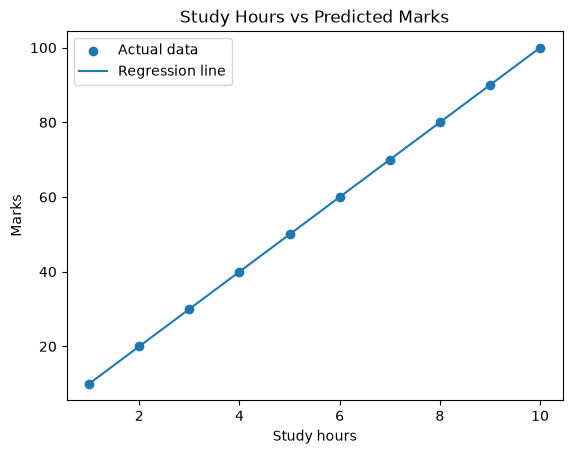

In [12]:
plt.scatter(X["study_hours"], y, label="Actual data")

hours = np.linspace(
    X["study_hours"].min(),
    X["study_hours"].max(),
    100
)

predicted_line = model.predict(
    pd.DataFrame({"study_hours": hours})
)

plt.plot(hours, predicted_line, label="Regression line")

plt.xlabel("Study hours")
plt.ylabel("Marks")
plt.title("Study Hours vs Predicted Marks")
plt.legend()
plt.show()